# Projeto Final: Prediçao de Vitórias em Partidas ranqueadas de League of Legends

Objetivo: Este projeto consiste em construir uma análise exploratória no dataset "League of Legends Diamond Ranked Games 10min", realizar o pré-processamento dos dados, tratamento se necessário, e desenvolver um modelo de Machine Learning utilizando este dataset.


## Importação das Bibliotecas Utilizadas

Utilizaremos as bibliotecas Pandas, Numpy, Matplotlib e Seaborn para construirmos a análise exploratória e em seguida aplicarmos modelos da biblioteca Sklearn e os avaliaremos de acordo com as métricas.

In [ ]:
import kagglehub

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

## Download e Carregamento do Dataset

Utilizaremos o Dataset League of Legends Diamond Ranked Games 10min, que consiste em dados de partidas ranqueadas do jogo League of Legends, de um determinado ranque nos seus primeiros 10 minutos de duração. O dataset contém informações e métricas que cada time obteve nos primeiros instantes da partida, e a partir disso, avaliaremos quais seus impactos nas vitórias.

In [ ]:
# Download latest version
path = kagglehub.dataset_download("bobbyscience/league-of-legends-diamond-ranked-games-10-min")

print("Path to dataset files:", path)

100%|██████████| 539k/539k [00:00<00:00, 88.0MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/bobbyscience/league-of-legends-diamond-ranked-games-10-min/versions/1


In [ ]:
df = pd.read_csv(path + '/high_diamond_ranked_10min.csv')

df.head()

,gameId,blueWins,blueWardsPlaced,blueWardsDestroyed,blueFirstBlood,blueKills,blueDeaths,blueAssists,blueEliteMonsters,blueDragons,...,redTowersDestroyed,redTotalGold,redAvgLevel,redTotalExperience,redTotalMinionsKilled,redTotalJungleMinionsKilled,redGoldDiff,redExperienceDiff,redCSPerMin,redGoldPerMin
0,4519157822,0,28,2,1,9,6,11,0,0,...,0,16567,6.8,17047,197,55,-643,8,19.7,1656.7
1,4523371949,0,12,1,0,5,5,5,0,0,...,1,17620,6.8,17438,240,52,2908,1173,24.0,1762.0
2,4521474530,0,15,0,0,7,11,4,1,1,...,0,17285,6.8,17254,203,28,1172,1033,20.3,1728.5
3,4524384067,0,43,1,0,4,5,5,1,0,...,0,16478,7.0,17961,235,47,1321,7,23.5,1647.8
4,4436033771,0,75,4,0,6,6,6,0,0,...,0,17404,7.0,18313,225,67,1004,-230,22.5,1740.4


## Exploração do Dataset

Nessa etapa avaliaremos como o dataset é composto e determinaremos a variável alvo que queremos avaliar. Também procuraremos valores faltantes, e se houver, faremos um tratamento para que essa ausência não impacte nos resultados.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9879 entries, 0 to 9878
Data columns (total 40 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   gameId                        9879 non-null   int64  
 1   blueWins                      9879 non-null   int64  
 2   blueWardsPlaced               9879 non-null   int64  
 3   blueWardsDestroyed            9879 non-null   int64  
 4   blueFirstBlood                9879 non-null   int64  
 5   blueKills                     9879 non-null   int64  
 6   blueDeaths                    9879 non-null   int64  
 7   blueAssists                   9879 non-null   int64  
 8   blueEliteMonsters             9879 non-null   int64  
 9   blueDragons                   9879 non-null   int64  
 10  blueHeralds                   9879 non-null   int64  
 11  blueTowersDestroyed           9879 non-null   int64  
 12  blueTotalGold                 9879 non-null   int64  
 13  blu

In [ ]:
df.describe()

,gameId,blueWins,blueWardsPlaced,blueWardsDestroyed,blueFirstBlood,blueKills,blueDeaths,blueAssists,blueEliteMonsters,blueDragons,...,redTowersDestroyed,redTotalGold,redAvgLevel,redTotalExperience,redTotalMinionsKilled,redTotalJungleMinionsKilled,redGoldDiff,redExperienceDiff,redCSPerMin,redGoldPerMin
count,9.879000e+03,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,...,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000,9879.000000
mean,4.500084e+09,0.499038,22.288288,2.824881,0.504808,6.183925,6.137666,6.645106,0.549954,0.361980,...,0.043021,16489.041401,6.925316,17961.730438,217.349226,51.313088,-14.414111,33.620306,21.734923,1648.904140
std,2.757328e+07,0.500024,18.019177,2.174998,0.500002,3.011028,2.933818,4.064520,0.625527,0.480597,...,0.216900,1490.888406,0.305311,1198.583912,21.911668,10.027885,2453.349179,1920.370438,2.191167,149.088841
min,4.295358e+09,0.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,11212.000000,4.800000,10465.000000,107.000000,4.000000,-11467.000000,-8348.000000,10.700000,1121.200000
25%,4.483301e+09,0.000000,14.000000,1.000000,0.000000,4.000000,4.000000,4.000000,0.000000,0.000000,...,0.000000,15427.500000,6.800000,17209.500000,203.000000,44.000000,-1596.000000,-1212.000000,20.300000,1542.750000
50%,4.510920e+09,0.000000,16.000000,3.000000,1.000000,6.000000,6.000000,6.000000,0.000000,0.000000,...,0.000000,16378.000000,7.000000,17974.000000,218.000000,51.000000,-14.000000,28.000000,21.800000,1637.800000
75%,4.521733e+09,1.000000,20.000000,4.000000,1.000000,8.000000,8.000000,9.000000,1.000000,1.000000,...,0.000000,17418.500000,7.200000,18764.500000,233.000000,57.000000,1585.500000,1290.500000,23.300000,1741.850000
max,4.527991e+09,1.000000,250.000000,27.000000,1.000000,22.000000,22.000000,29.000000,2.000000,1.000000,...,2.000000,22732.000000,8.200000,22269.000000,289.000000,92.000000,10830.000000,9333.000000,28.900000,2273.200000


In [ ]:
df.isnull().sum()

,0
gameId,0
blueWins,0
blueWardsPlaced,0
blueWardsDestroyed,0
blueFirstBlood,0
blueKills,0
blueDeaths,0
blueAssists,0
blueEliteMonsters,0
blueDragons,0


## Entendimento da Variável alvo

Após verificar a composição do dataset e verificar que não existem valores nulos, escolheremos a variável alvo (blueWins) que consiste numa variável binária onde o valor 0 significa que o time azul perdeu o jogo e o valor 1 significa que o time azul venceu o jogo.

/tmp/ipykernel_841/1267831692.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='blueWins', data=df, palette='Set2')


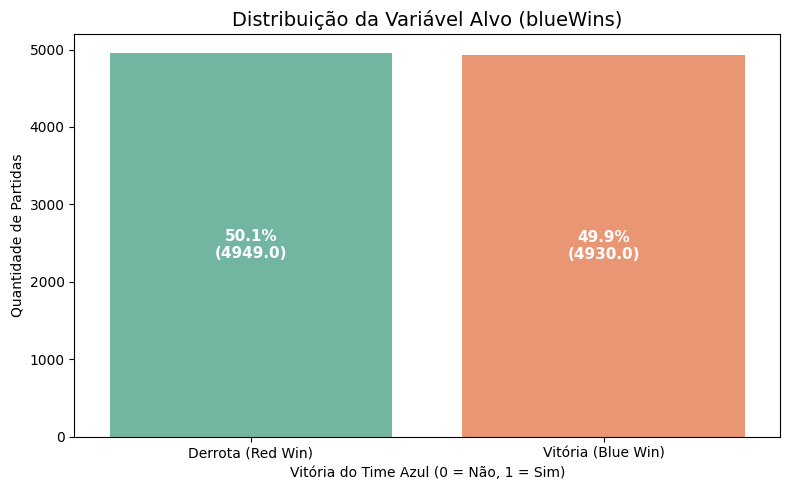

In [ ]:
# 3. Análise da Variável Alvo (blueWins)

plt.figure(figsize=(8,5))

ax = sns.countplot(x='blueWins', data=df, palette='Set2')
plt.title('Distribuição da Variável Alvo (blueWins)', fontsize=14)
plt.xlabel('Vitória do Time Azul (0 = Não, 1 = Sim)')
plt.ylabel('Quantidade de Partidas')
plt.xticks([0, 1], ['Derrota (Red Win)', 'Vitória (Blue Win)'])

total = len(df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%\n({p.get_height()})'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height() / 2
    ax.annotate(percentage, (x, y), ha='center', va='center', fontsize=11, color='white', weight='bold')

plt.tight_layout()
plt.show()

Neste tópico também buscaremos entender como as demais variáveis impactam na variável alvo (bluewins).

/tmp/ipykernel_841/1614156671.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_corr.values, y=top_corr.index, palette='vlag')


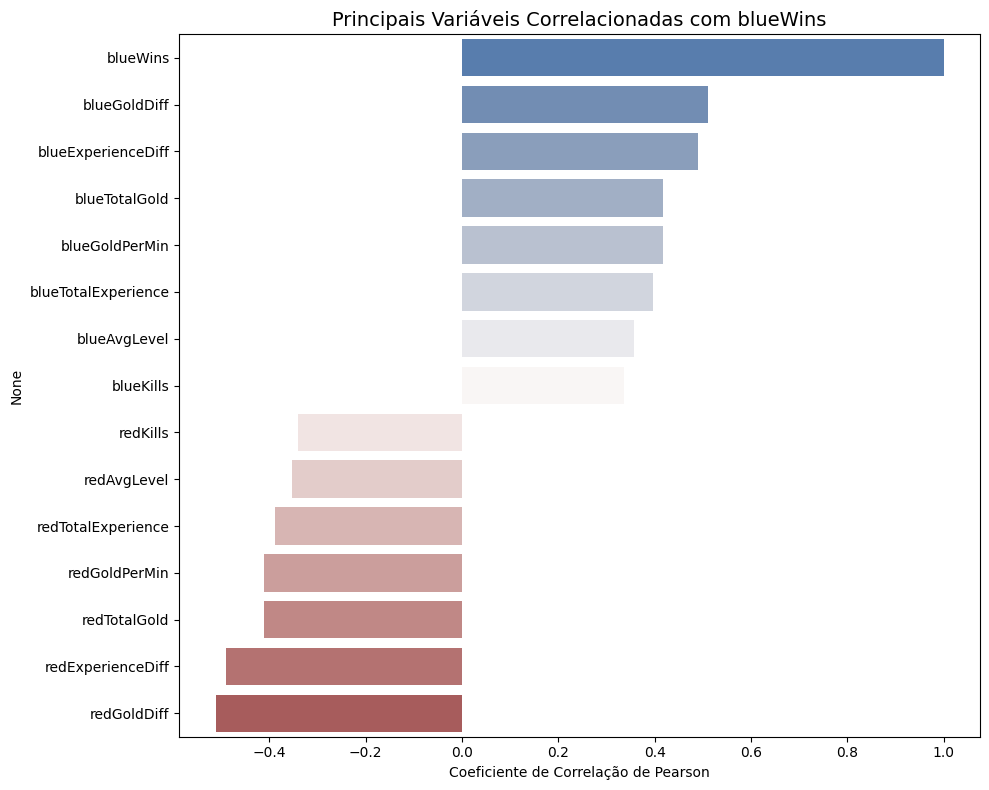

In [ ]:
# 4. Matriz de Correlação com a Variável Alvo

correlations = df.corr()['blueWins'].sort_values(ascending=False)

plt.figure(figsize=(10, 8))
top_corr = pd.concat([correlations.head(8), correlations.tail(7)])
sns.barplot(x=top_corr.values, y=top_corr.index, palette='vlag')
plt.title('Principais Variáveis Correlacionadas com blueWins', fontsize=14)
plt.xlabel('Coeficiente de Correlação de Pearson')
plt.tight_layout()
plt.show()

Como variáveis mais impactantes temos a diferença de Ouro e Experiência entre os times, então compararemos como ambas se comportam em cada cenário.

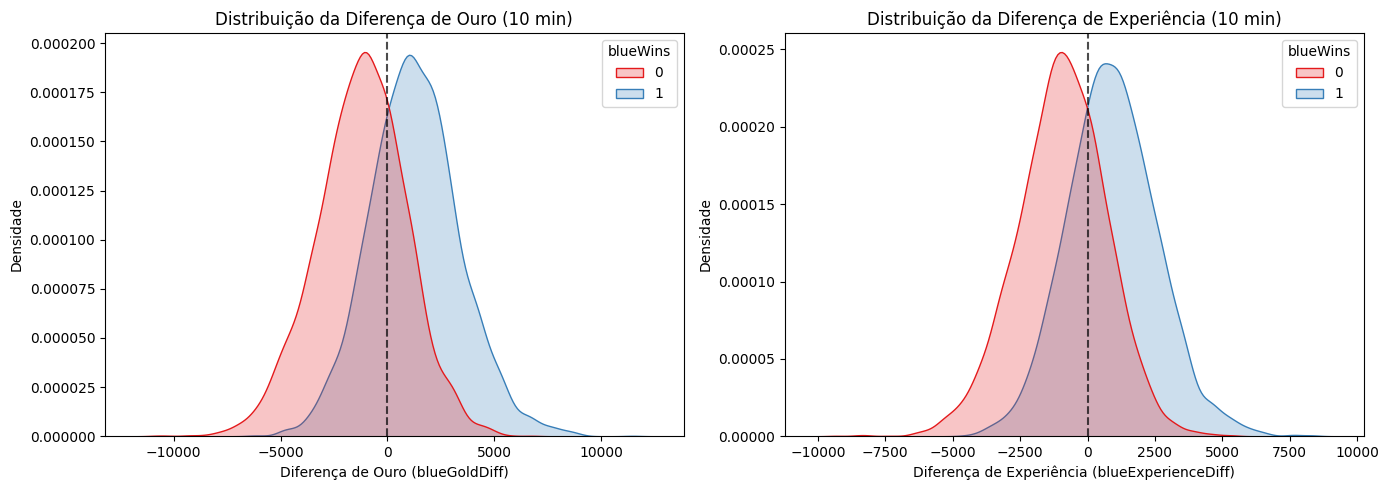

In [ ]:
# 5. Distribuição de Ouro e Experiência vs Vitória
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Diferença de Ouro vs Vitória
sns.kdeplot(data=df, x='blueGoldDiff', hue='blueWins', fill=True, common_norm=False, palette='Set1', ax=axes[0])
axes[0].set_title('Distribuição da Diferença de Ouro (10 min)', fontsize=12)
axes[0].set_xlabel('Diferença de Ouro (blueGoldDiff)')
axes[0].set_ylabel('Densidade')
axes[0].axvline(0, color='black', linestyle='--', alpha=0.7)

# Diferença de Experiência vs Vitória
sns.kdeplot(data=df, x='blueExperienceDiff', hue='blueWins', fill=True, common_norm=False, palette='Set1', ax=axes[1])
axes[1].set_title('Distribuição da Diferença de Experiência (10 min)', fontsize=12)
axes[1].set_xlabel('Diferença de Experiência (blueExperienceDiff)')
axes[1].set_ylabel('Densidade')
axes[1].axvline(0, color='black', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

De maneira similar, verificaremos como a execução de um Dragão e a ocorrência de FirstBlood se relacionam com a vitória de um time.

/tmp/ipykernel_841/857757308.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='blueDragons', y='blueWins', data=dragons_winrate, palette='Blues_d', ax=axes[0])
/tmp/ipykernel_841/857757308.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='blueFirstBlood', y='blueWins', data=fb_winrate, palette='Greens_d', ax=axes[1])


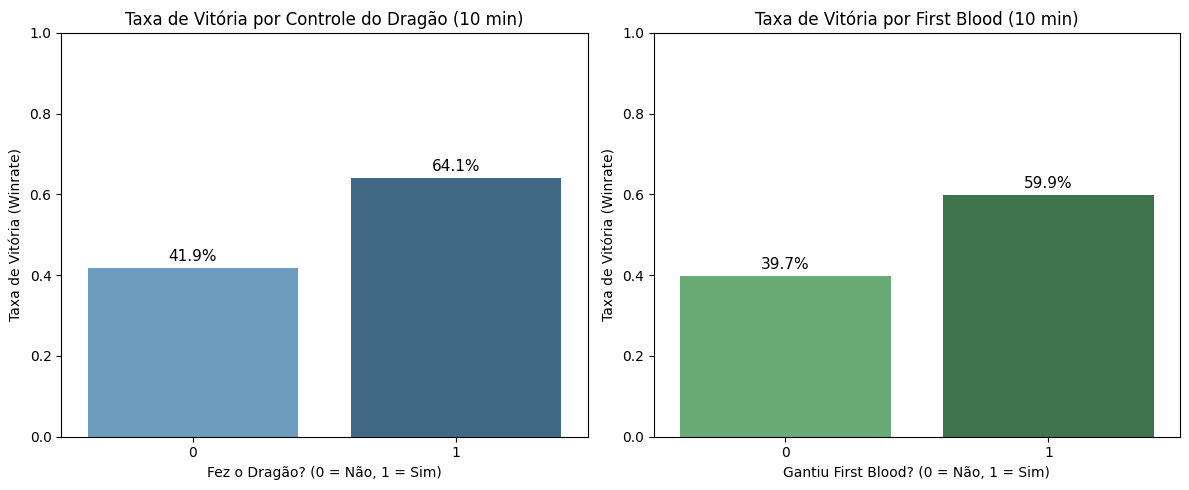

In [ ]:
# 6. Impacto de Objetivos Precoces (Dragão e First Blood)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Impacto do Dragão
dragons_winrate = df.groupby('blueDragons')['blueWins'].mean().reset_index()
sns.barplot(x='blueDragons', y='blueWins', data=dragons_winrate, palette='Blues_d', ax=axes[0])
axes[0].set_title('Taxa de Vitória por Controle do Dragão (10 min)', fontsize=12)
axes[0].set_xlabel('Fez o Dragão? (0 = Não, 1 = Sim)')
axes[0].set_ylabel('Taxa de Vitória (Winrate)')
axes[0].set_ylim(0, 1)
for p in axes[0].patches:
    axes[0].annotate(f"{p.get_height()*100:.1f}%", (p.get_x() + p.get_width()/2., p.get_height()),
                     ha='center', va='bottom', fontsize=11, xytext=(0, 3), textcoords='offset points')

# Impacto do First Blood
fb_winrate = df.groupby('blueFirstBlood')['blueWins'].mean().reset_index()
sns.barplot(x='blueFirstBlood', y='blueWins', data=fb_winrate, palette='Greens_d', ax=axes[1])
axes[1].set_title('Taxa de Vitória por First Blood (10 min)', fontsize=12)
axes[1].set_xlabel('Gantiu First Blood? (0 = Não, 1 = Sim)')
axes[1].set_ylabel('Taxa de Vitória (Winrate)')
axes[1].set_ylim(0, 1)
for p in axes[1].patches:
    axes[1].annotate(f"{p.get_height()*100:.1f}%", (p.get_x() + p.get_width()/2., p.get_height()),
                     ha='center', va='bottom', fontsize=11, xytext=(0, 3), textcoords='offset points')

plt.tight_layout()
plt.show()

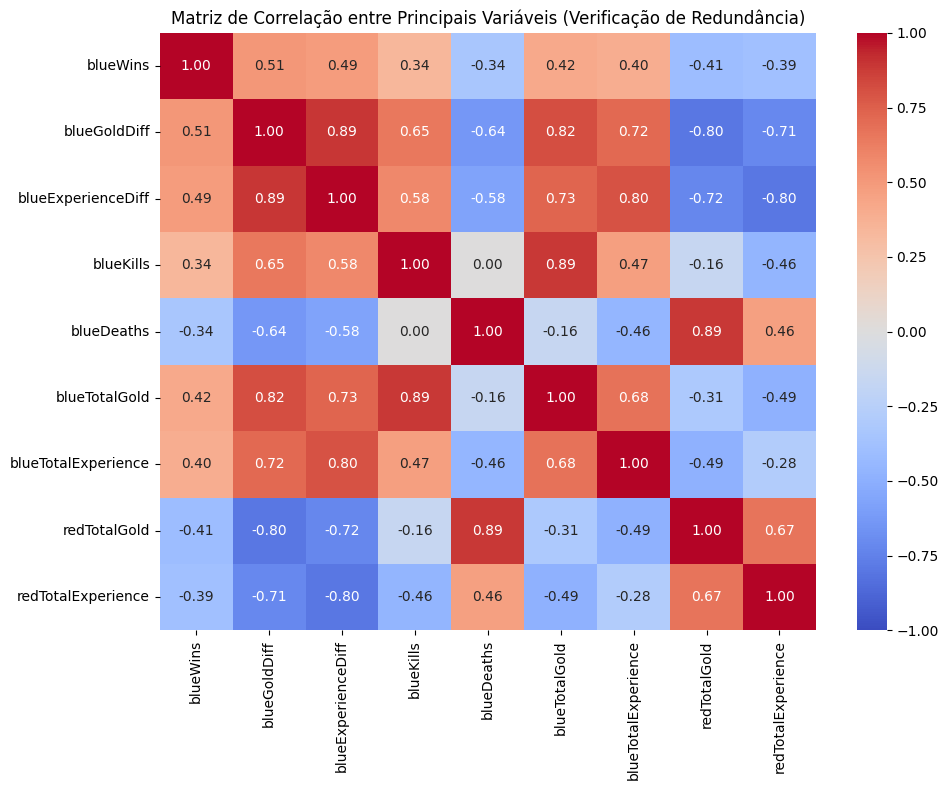

In [ ]:
# 7. Análise de Multicolinearidade (Heatmap)
plt.figure(figsize=(10, 8))
key_features = [
    'blueWins', 'blueGoldDiff', 'blueExperienceDiff',
    'blueKills', 'blueDeaths', 'blueTotalGold', 'blueTotalExperience',
    'redTotalGold', 'redTotalExperience'
]
sns.heatmap(df[key_features].corr(), annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Matriz de Correlação entre Principais Variáveis (Verificação de Redundância)', fontsize=12)
plt.tight_layout()
plt.show()

## Conclusões

1. Taxa de Vitória x Desempenho do Time
  * Os índices de ouro e experiência indicam impacto considerável na vitória de um time.

2. Taxa de Vitória x Objetivos
  * A execução de objetivos ou sucesso em confrontos indicam impacto consideravel na vitória de um time.


## Pré-Processamento

A partir dos insights obtidos, separaremos as variáveis em X como variáveis independentes do modelo e Y como a variável que queremos prever.

Neste caso, utilizaremos uma nova variável independente chamada de "blueGoldDiff", que consiste na diferença entre a quantidade de ouro dos dois times.

Também separaremos o dataset em dois conjuntos:
* 80% das entradas como treino
* 20% das entradas como teste

In [ ]:
X = df.drop(columns=['blueWins'])
y = df['blueWins']

if 'blueGoldDiff' not in X.columns:
    X['blueGoldDiff'] = X['blueTotalGold'] - X['redTotalGold']
if 'blueExpDiff' not in X.columns:
    X['blueExpDiff'] = X['blueTotalExperience'] - X['redTotalExperience']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


Como cada variável possui uma escala de valores diferentes, aplicaremos um escalonador para padronizar os valores.

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Modelo Base

Utilizaremos a Regressão Logística como modelo padrão e a partir dele avaliaremos os outros modelos.

A escolha da Regressão Logística consiste na natureza binária do problema, sendo 0 a derrota do time azul e 1 a vitória do time azul.

In [27]:
modelo = LogisticRegression(max_iter=1000)
modelo.fit(X_train_scaled, y_train)


LogisticRegression(max_iter=1000)

## Avaliaçao do Modelo Base

Utilizaremos as métricas 'Accuracy', 'precision', 'recall' e 'f1-score' para avaliar o desempenho do modelo, assim, poderemos comparar com os demais.

In [28]:
y_pred = modelo.predict(X_test_scaled)
print(f'Acurácia: {accuracy_score(y_test, y_pred):.4f}')
print(classification_report(y_test, y_pred))

Acurácia: 0.7333
              precision    recall  f1-score   support

           0       0.73      0.73      0.73       983
           1       0.73      0.74      0.73       993

    accuracy                           0.73      1976
   macro avg       0.73      0.73      0.73      1976
weighted avg       0.73      0.73      0.73      1976



Também utilizaremos uma Matriz de Confusão para entender a precisão do modelo, uma vez que os dados podem ser previstos incorretamente.

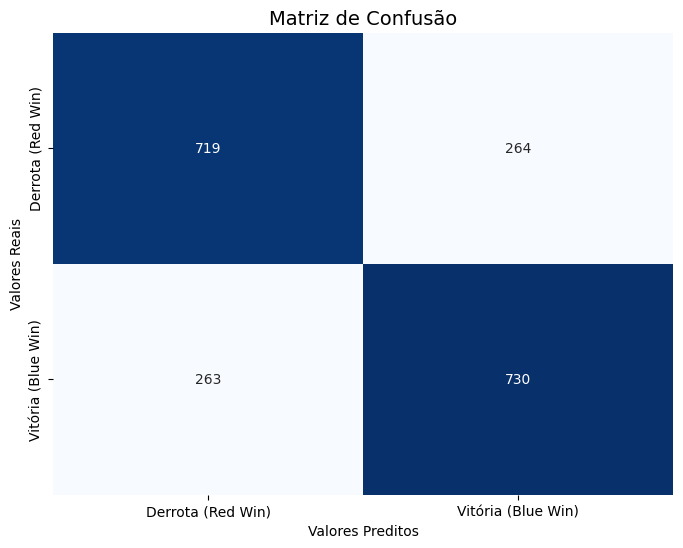

In [ ]:
confmatrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(confmatrix, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Derrota (Red Win)', 'Vitória (Blue Win)'],
            yticklabels=['Derrota (Red Win)', 'Vitória (Blue Win)'])
plt.title('Matriz de Confusão', fontsize=14)
plt.xlabel('Valores Preditos')
plt.ylabel('Valores Reais')
plt.show()

## Comparação entre os modelos

Importaremos da Biblioteca Sklearn os modelos:
* K-Nearest Neighboors (KNN)
* Árvore de Decisão
* Random Forest
* Support Vector Machine (SVM)

E após treinos e testes, avaliaremos as mesmas métricas:
* Accuracy
* Precision
* Recall
* F1-Score

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score)

Definição dos Modelos: Um dicionário models é criado, onde cada chave é o nome de um algoritmo (Regressão Logística, Random Forest, Árvore de Decisão, K-Nearest Neighbors e Support Vector Machine) e o valor é uma instância configurada desse modelo.

* Iteração e Treinamento: O código itera sobre cada modelo no dicionário models.

* Seleção de Dados (X_data): X_data é definido como X_train_scaled (os dados de treino escalados).

* Validação Cruzada (cross_val_score): cross_val_score(model, X_data, y_train, cv=5, scoring='roc_auc') executa a validação cruzada para cada modelo:

  * Ele divide o conjunto de treino (X_data, y_train) em 5 'folds' (subconjuntos).
  * Em cada iteração, ele treina o modelo em 4 folds e testa no fold restante.
  * O scoring='roc_auc' indica que a métrica de avaliação usada é a Área Sob a Curva ROC, que é uma boa métrica para problemas de classificação binária, especialmente quando as classes estão desbalanceadas ou você quer uma visão do desempenho do classificador em vários limites de decisão.
  * cv_scores armazena as 5 pontuações ROC AUC obtidas em cada fold.
* Armazenamento e Impressão de Resultados: A média das pontuações de validação cruzada (cv_scores.mean()) é armazenada no dicionário results para cada modelo.

In [29]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Árvore de Decisão": DecisionTreeClassifier(random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Support Vector Machine": SVC(random_state=42)
}

results = {}
for name, model in models.items():
    # Usando X_train_scaled para todos os modelos para padronizar a comparação
    X_data = X_train_scaled
    cv_scores = cross_val_score(model, X_data, y_train, cv=5, scoring='roc_auc')
    results[name] = cv_scores.mean()
    print(f"Modelo: {name} | Cross-Val Score: {cv_scores.mean():.4f}")

Modelo: Logistic Regression | Cross-Val Score: 0.8080
Modelo: Random Forest | Cross-Val Score: 0.7934
Modelo: Árvore de Decisão | Cross-Val Score: 0.6287
Modelo: K-Nearest Neighbors | Cross-Val Score: 0.7409
Modelo: Support Vector Machine | Cross-Val Score: 0.7850


Para utilizar as métricas estabelecidas previamente, faremos novamente iterações sobre os modelos e armazenaremos as métricas em um dataframe.

In [ ]:
resultados = []

for nome, modelo in models.items():
    modelo.fit(X_train_scaled, y_train)
    y_pred = modelo.predict(X_test_scaled)

    resultados.append({
        'Modelo': nome,
        'Acurácia': accuracy_score(y_test, y_pred),
        'CrossVal Score': cross_val_score(modelo, X_train_scaled, y_train, cv=5, scoring='roc_auc').mean(),
        'Precisão': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred)
    })

df_resultados = pd.DataFrame(resultados)
df_resultados.head()

,Modelo,Acurácia,CrossVal Score,Precisão,Recall,F1-Score
0,Logistic Regression,0.733300,0.807956,0.734406,0.735146,0.734776
1,Random Forest,0.719636,0.793424,0.727934,0.705942,0.716769
2,Árvore de Decisão,0.626518,0.628709,0.628658,0.627392,0.628024
3,K-Nearest Neighbors,0.690789,0.740898,0.699791,0.673716,0.686506
4,Support Vector Machine,0.723684,0.784959,0.729231,0.716012,0.722561


## Escolha melhor modelo e Otimização

Como obtivemos melhores métricas com a Regressão Logística, a utilizaremos para otimiza-la com o GridSeach, que consiste em buscar os melhores hiperparâmetros e poderemos testa-los para verificar sua performance.

In [34]:
from sklearn.model_selection import GridSearchCV

lreg = LogisticRegression(max_iter=5000) # Aumentando o número de iterações

param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga']
}

grid_search = GridSearchCV(lreg, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train_scaled, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


GridSearchCV(cv=5, estimator=LogisticRegression(max_iter=5000),
             param_grid={'C': [0.001, 0.01, 0.1, 1, 10, 100],
                         'penalty': ['l1', 'l2'],
                         'solver': ['liblinear', 'saga']},
             scoring='accuracy')

## Melhores parâmetros

Após a execução do GridSeach, é apresentado os melhores parâmetros encontrados:

In [35]:
print("Melhores parametros")
print(grid_search.best_params_)

Melhores parametros
{'C': 0.01, 'penalty': 'l1', 'solver': 'saga'}


## Otimização do Modelo

Após encontrar a execução dos melhores parâmetros, os utilizaremos novamente em um modelo de Regressão Linear, e avaliaremos suas métricas.

In [36]:
modelo_otimizado = grid_search.best_estimator_

pred_otimizado = modelo_otimizado.predict(X_test_scaled)

print(f'Acurácia:{accuracy_score(y_test, pred_otimizado):.4f}')
print(classification_report(y_test, pred_otimizado))

Acurácia:0.7318
              precision    recall  f1-score   support

           0       0.73      0.73      0.73       983
           1       0.73      0.74      0.73       993

    accuracy                           0.73      1976
   macro avg       0.73      0.73      0.73      1976
weighted avg       0.73      0.73      0.73      1976



## Conclusão

Este projeto teve como objetivo principal a construção de um modelo preditivo para vitórias em partidas ranqueadas de League of Legends, utilizando o dataset "League of Legends Diamond Ranked Games 10min". Através de uma análise exploratória, identificamos que métricas de início de partida, como diferença de ouro (blueGoldDiff), diferença de experiência (blueExperienceDiff) e o controle de objetivos como Dragão e First Blood, são altamente correlacionadas com o resultado final da partida. Após o pré-processamento dos dados, que incluiu a criação de novas features e o escalonamento, diversos modelos de Machine Learning (Regressão Logística, Random Forest, Árvore de Decisão, K-Nearest Neighbors e Support Vector Machine) foram avaliados. A Regressão Logística se destacou inicialmente, e uma otimização de hiperparâmetros foi realizada com GridSearchCV. Embora o GridSearchCV tenha identificado os melhores parâmetros para a Regressão Logística, a acurácia do modelo otimizado permaneceu consistente com a do modelo base. No geral, o projeto demonstra a alta capacidade de predição do resultado de uma partida a partir de eventos dos 10 primeiros minutos, confirmando a relevância de um bom início de jogo no League of Legends.